In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import yfinance as yf

In [4]:
def normalize(prices):
    initialPrice = prices.iloc[0]
    return (prices - initialPrice) / initialPrice

tickers = ["AAPL", "MSFT", "GOOG", "NVDA", "ADBE", "ORCL", "INTC", "TXN", "AMD", "PYPL",
           "JPM", "BAC", "C", "GS", "MS", "BRK-A", "V", "MA", "AXP", "BLK",
           "TSLA", "NKE", "HD", "LOW", "SBUX", "MCD", "TGT", "TJX", "LULU", "SONO",
           "GE", "CAT", "BA", "MMM", "HON", "ITW", "UNP", "LMT", "FDX", "RTX",
           "NEE", "DUK", "SO", "D", "AEP", "EXC", "XEL", "SRE", "PEG", "CNP",
           "LLY", "JNJ", "ABBV", "MRK", "PFE", "AMGN", "GILD", "ISRG", "HCA", "UNH",
           "XOM","CVX","COP","EOG","SLB","OXY","DVN","FANG","LNG","HAL",
           "PG","KO","PEP","WMT","COST","CL","KMB","GIS","HSY","MKC",
           "AMT","PLD","EQIX","O","SPG","WELL","DLR","AVB","EQR","VICI",
           "META","NFLX","DIS","TMUS","VZ","T","CHTR","PSKY","CMCSA","WBD"]

timeSeries = yf.download(tickers, start="2019-01-01", auto_adjust="true")["Close"]
tickersUsed = timeSeries.columns.tolist()
normalizedSeries = timeSeries.apply(normalize, axis=0)
target = torch.tensor(normalizedSeries.values.T, dtype=torch.float32).unsqueeze(-1)
nTickers, nTimeSteps, _ = target.shape

[*********************100%***********************]  100 of 100 completed


In [5]:
def normalize(prices):
    initialPrice = prices.iloc[0]
    return (prices - initialPrice) / initialPrice


class lstm(nn.Module):
    def __init__(self, nTickers):
        super().__init__()
        self.hiddenLayers = 128
        self.h0      = nn.Parameter(torch.zeros(nTickers, 128))
        self.lstmCell = nn.LSTMCell(1, 128)
        self.fc      = nn.Linear(128, 1)

    def forward(self, idx, nTimeSteps):
        h = self.h0[idx]
        c = torch.zeros(len(idx), 128)
        x = torch.zeros(len(idx), 1)
        outputs = []
        for i in range(nTimeSteps):
            h, c = self.lstmCell(x, (h, c))
            x    = self.fc(h)
            outputs.append(x)
        return torch.stack(outputs, dim=1)


def plotLoss(lossHistory):
    epochs, losses = zip(*lossHistory)
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, losses, color="steelblue", linewidth=1.2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Training Loss")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

    
def plotPCA(model, tickersUsed):
    h0_np = model.h0.detach().numpy()
    h0_2d = PCA(n_components=2).fit_transform(h0_np)
    fig, ax = plt.subplots(figsize=(12, 9))
    for ticker, (x, y) in zip(tickersUsed, h0_2d):
        ax.scatter(x, y, color="steelblue", s=60, alpha=0.75)
        ax.annotate(ticker, (x, y), fontsize=7, alpha=0.85,
                    xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_title("Initial Hidden States h₀ — PCA")
    plt.tight_layout()
    plt.show()

In [6]:
model     = lstm(nTickers)
optimizer = Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
lossHistory = []

for epoch in range(50000):
    idx  = torch.randperm(nTickers)[:64]
    loss = criterion(model(idx, nTimeSteps), target[idx])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        lossHistory.append((epoch, loss.item()))
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

Epoch 0 | Loss: 10.215891
Epoch 50 | Loss: 10.522670
Epoch 100 | Loss: 10.720837
Epoch 150 | Loss: 3.098283
Epoch 200 | Loss: 10.894603
Epoch 250 | Loss: 10.871235
Epoch 300 | Loss: 2.687292
Epoch 350 | Loss: 10.842201
Epoch 400 | Loss: 11.065997
Epoch 450 | Loss: 9.304661
Epoch 500 | Loss: 2.925614
Epoch 550 | Loss: 8.898932
Epoch 600 | Loss: 2.816574
Epoch 650 | Loss: 3.006049
Epoch 700 | Loss: 2.876178
Epoch 750 | Loss: 0.985143
Epoch 800 | Loss: 2.501627
Epoch 850 | Loss: 10.991362
Epoch 900 | Loss: 10.839484
Epoch 950 | Loss: 10.660355
Epoch 1000 | Loss: 10.989949
Epoch 1050 | Loss: 2.484044
Epoch 1100 | Loss: 9.424871
Epoch 1150 | Loss: 9.166584
Epoch 1200 | Loss: 10.786620
Epoch 1250 | Loss: 2.750756
Epoch 1300 | Loss: 8.853851
Epoch 1350 | Loss: 1.008842
Epoch 1400 | Loss: 1.364681
Epoch 1450 | Loss: 9.436289
Epoch 1500 | Loss: 9.150260
Epoch 1550 | Loss: 8.928130
Epoch 1600 | Loss: 10.735358
Epoch 1650 | Loss: 2.731657
Epoch 1700 | Loss: 10.807206
Epoch 1750 | Loss: 1.410419
E

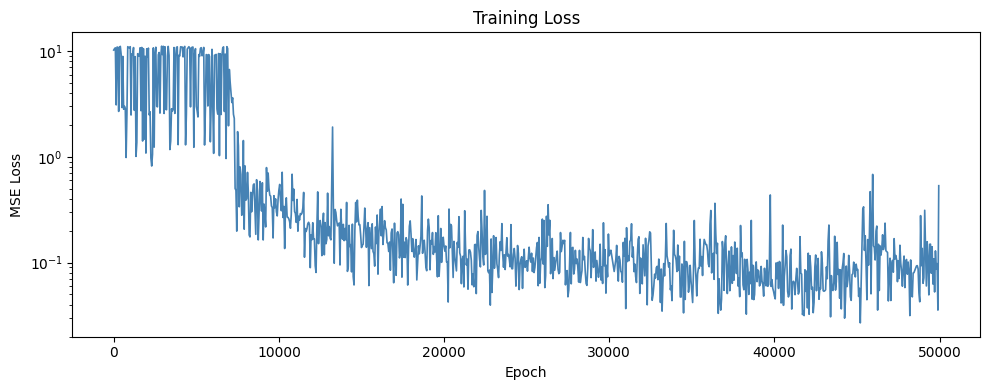

In [7]:
plotLoss(lossHistory)

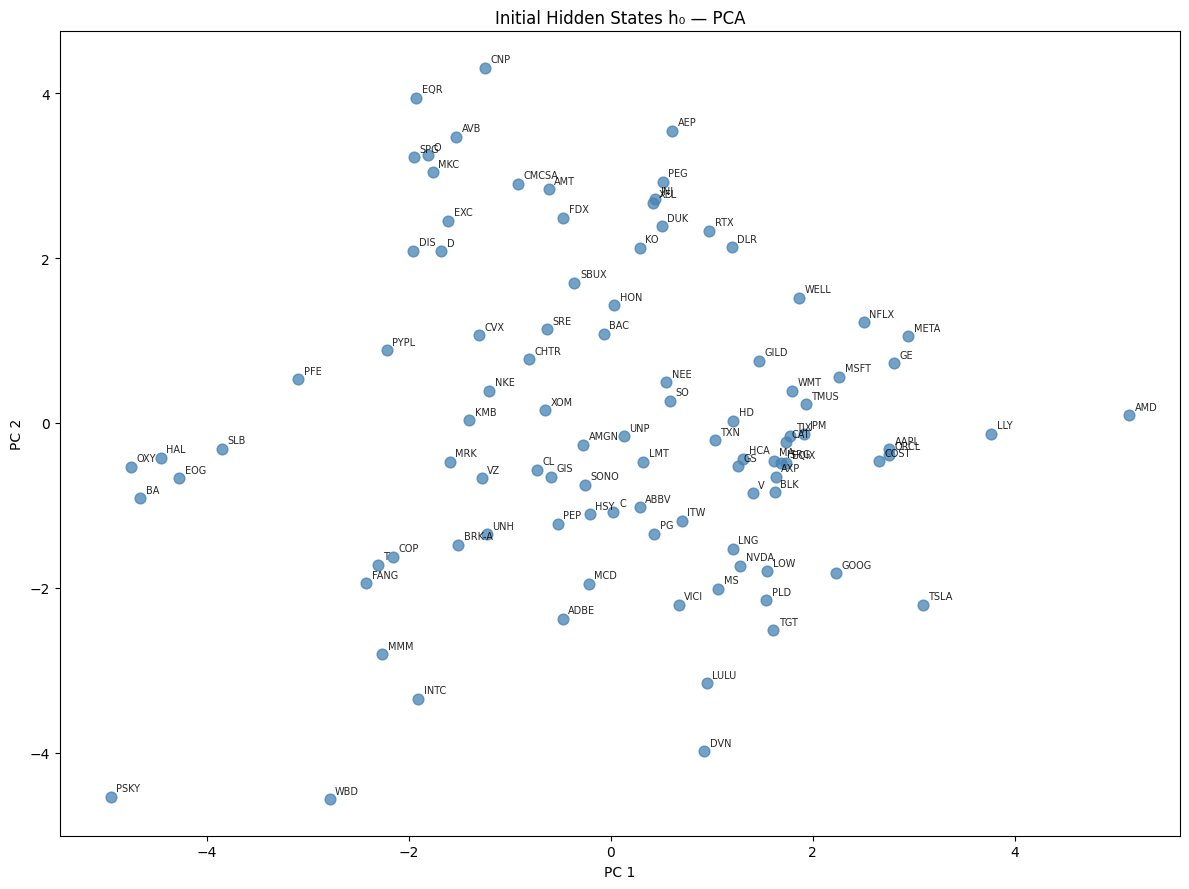

In [8]:
plotPCA(model, tickersUsed)